# 💳 Fraud Detection Using Machine Learning

## Introduction

Fraud detection is an important application of Machine Learning in the financial sector. The main objective of this project is to identify whether a financial transaction is **genuine or fraudulent** based on different transaction-related features.

A major challenge in this dataset is **class imbalance**, because the number of fraudulent transactions is much smaller than the number of genuine transactions. To address this problem, **SMOTE (Synthetic Minority Over-sampling Technique)** is applied to the training data.

The project includes **data exploration, preprocessing, stratified train-test splitting, class imbalance handling, and Machine Learning model training**. **Logistic Regression and Random Forest** are used for classification. The models are evaluated using **Precision, Recall, F1-Score, and ROC-AUC**, which provide a better understanding of fraud detection performance than accuracy alone.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings

warnings.filterwarnings("ignore")


print("All required libraries imported successfully!")



All required libraries imported successfully!


In [20]:
df = pd.read_csv("credit_card_fraud_10k.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Count each class
class_counts = df["is_fraud"].value_counts()

print("\nClass Counts:")


# Calculate percentages
class_percentages = df["is_fraud"].value_counts(normalize=True) * 100

print("\nClass Percentages:")
print(class_percentages)

# Fraud percentage
fraud_percentage = (
    df["is_fraud"].value_counts(normalize=True).get(1, 0) * 100
)

print(f"\nPercentage of fraudulent transactions: {fraud_percentage:.2f}%")

Dataset Shape: (10000, 10)

First 5 rows:
   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
1                  1              64         0  
2                  1         

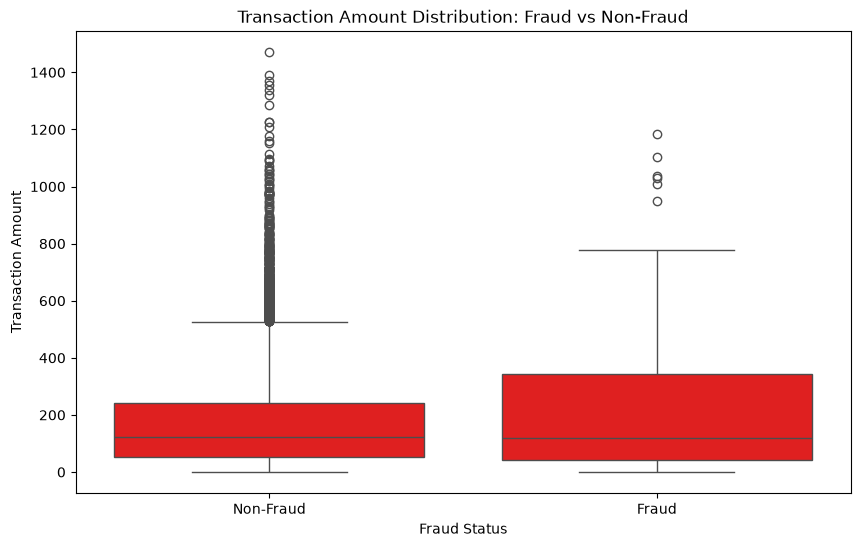

In [21]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="amount",
    color="red"
)

plt.xlabel("Fraud Status")
plt.ylabel("Transaction Amount")
plt.title("Transaction Amount Distribution: Fraud vs Non-Fraud")

plt.xticks(
    [0, 1],
    ["Non-Fraud", "Fraud"]
)

plt.show()

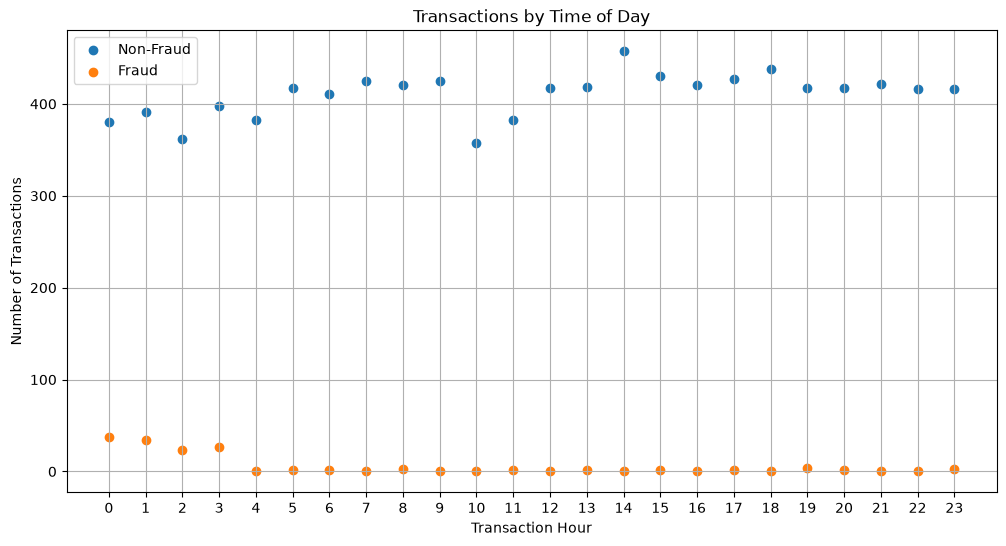

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Count transactions for each hour and fraud status
hourly_counts = (
    df.groupby(["transaction_hour", "is_fraud"])
      .size()
      .unstack(fill_value=0)
)

# Scatter plot for Non-Fraud
plt.scatter(
    hourly_counts.index,
    hourly_counts[0],
    marker="o",
    label="Non-Fraud"
)

# Scatter plot for Fraud
plt.scatter(
    hourly_counts.index,
    hourly_counts[1],
    marker="o",
    label="Fraud"
)

plt.xlabel("Transaction Hour")
plt.ylabel("Number of Transactions")
plt.title("Transactions by Time of Day")
plt.xticks(range(24))
plt.legend()
plt.grid(True)

plt.show()

## Q3 - Why Accuracy Is a Misleading Metric for Fraud Detection

Accuracy is not a reliable metric for this fraud detection problem because the dataset is highly imbalanced.

Only 1.51% of the transactions in this dataset are fraudulent, while approximately 98.49% are legitimate.

For example, a model that predicts every transaction as non-fraudulent would achieve approximately 98.49% accuracy. However, that model would detect 0 fraudulent transactions.

Therefore, high accuracy does not necessarily mean that the model is useful for fraud detection.

For this reason, we focus on Precision, Recall, F1-Score, and ROC-AUC.

Recall is particularly important because it measures the proportion of actual fraudulent transactions that the model successfully identifies.

In [23]:
# Load dataset
df = pd.read_csv("credit_card_fraud_10k.csv")

# Features
X = df.drop(columns=["is_fraud", "transaction_id"])

# Target
y = df["is_fraud"]

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training data shape: (8000, 8)
Testing data shape: (2000, 8)

Training class distribution:
is_fraud
0    7879
1     121
Name: count, dtype: int64

Testing class distribution:
is_fraud
0    1970
1      30
Name: count, dtype: int64


In [24]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

categorical_features = ["merchant_category"]

numerical_features = [
    "amount",
    "transaction_hour",
    "foreign_transaction",
    "location_mismatch",
    "device_trust_score",
    "velocity_last_24h",
    "cardholder_age"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (8000, 12)
Processed testing shape: (2000, 12)


In [25]:
# Check original class distribution
print("Original training class distribution:")
print(y_train.value_counts())

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Original training class distribution:
is_fraud
0    7879
1     121
Name: count, dtype: int64

Class distribution after SMOTE:
is_fraud
0    7879
1    7879
Name: count, dtype: int64


In [26]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_smote,
    y_train_smote
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [27]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_smote,
    y_train_smote
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [28]:
# Predictions
logistic_predictions = logistic_model.predict(X_test_processed)

# Fraud probabilities
logistic_probabilities = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

# Metrics
logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

print("Logistic Regression Results")
print("--------------------------------")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")
print(f"F1-Score:  {logistic_f1:.4f}")
print(f"ROC-AUC:   {logistic_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

Logistic Regression Results
--------------------------------
Precision: 0.2871
Recall:    0.9667
F1-Score:  0.4427
ROC-AUC:   0.9933

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.29      0.97      0.44        30

    accuracy                           0.96      2000
   macro avg       0.64      0.97      0.71      2000
weighted avg       0.99      0.96      0.97      2000



In [29]:
random_forest_predictions = random_forest_model.predict(
    X_test_processed
)

random_forest_probabilities = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

random_forest_precision = precision_score(
    y_test,
    random_forest_predictions,
    zero_division=0
)

random_forest_recall = recall_score(
    y_test,
    random_forest_predictions,
    zero_division=0
)

random_forest_f1 = f1_score(
    y_test,
    random_forest_predictions,
    zero_division=0
)

random_forest_auc = roc_auc_score(
    y_test,
    random_forest_probabilities
)

print("Random Forest Results")
print("--------------------------------")
print(f"Precision: {random_forest_precision:.4f}")
print(f"Recall:    {random_forest_recall:.4f}")
print(f"F1-Score:  {random_forest_f1:.4f}")
print(f"ROC-AUC:   {random_forest_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        random_forest_predictions,
        zero_division=0
    )
)

Random Forest Results
--------------------------------
Precision: 1.0000
Recall:    0.6333
F1-Score:  0.7755
ROC-AUC:   0.9993

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       1.00      0.63      0.78        30

    accuracy                           0.99      2000
   macro avg       1.00      0.82      0.89      2000
weighted avg       0.99      0.99      0.99      2000



In [30]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        logistic_precision,
        random_forest_precision
    ],
    "Recall": [
        logistic_recall,
        random_forest_recall
    ],
    "F1-Score": [
        logistic_f1,
        random_forest_f1
    ],
    "ROC-AUC": [
        logistic_auc,
        random_forest_auc
    ]
})

print(results.round(4))

                 Model  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression     0.2871  0.9667    0.4427   0.9933
1        Random Forest     1.0000  0.6333    0.7755   0.9993


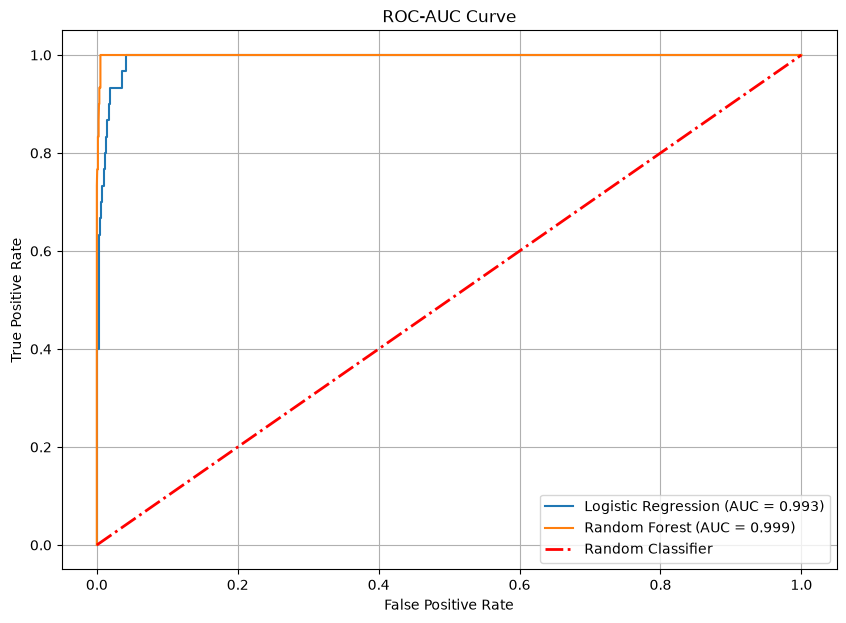

In [31]:
# Logistic Regression ROC
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    logistic_probabilities
)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    random_forest_probabilities
)

# Plot
plt.figure(figsize=(10, 7))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {random_forest_auc:.3f})"
)

# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="-.",
    label="Random Classifier",
    color="red",
    lw=2
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")

plt.legend()
plt.grid(True)

plt.show()

##  Precision vs Recall in Fraud Detection

There is a trade-off between Precision and Recall in fraud detection.

### Recall

Recall measures the percentage of actual fraudulent transactions that are correctly detected.

Recall = True Positives / (True Positives + False Negatives)

A high Recall means that fewer fraudulent transactions are missed.

This can be important in fraud detection because a false negative means that a fraudulent transaction was classified as legitimate.

### Precision

Precision measures the percentage of transactions predicted as fraudulent that are actually fraudulent.

Precision = True Positives / (True Positives + False Positives)

A high Precision means that fewer legitimate transactions are incorrectly flagged as fraud.

### Trade-off

Increasing Recall can result in more legitimate transactions being flagged as suspicious, reducing Precision.

Increasing Precision can result in fewer legitimate transactions being flagged, but potentially more fraudulent transactions being missed.

Therefore, the appropriate balance depends on the business cost of false positives and false negatives.

For a fraud detection system where missing fraudulent transactions is particularly costly, Recall may receive greater emphasis. However, Precision must also be monitored because excessive false alerts can inconvenience legitimate customers and increase manual investigation costs.

F1-Score can be used as a balanced summary of Precision and Recall when both are important.

In [32]:
feature_names = preprocessor.get_feature_names_out()

print("Processed Features:")
for feature in feature_names:
    print(feature)

Processed Features:
numerical__amount
numerical__transaction_hour
numerical__foreign_transaction
numerical__location_mismatch
numerical__device_trust_score
numerical__velocity_last_24h
numerical__cardholder_age
categorical__merchant_category_Clothing
categorical__merchant_category_Electronics
categorical__merchant_category_Food
categorical__merchant_category_Grocery
categorical__merchant_category_Travel


In [33]:
logistic_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": logistic_model.coef_[0]
})

# Absolute coefficient magnitude
logistic_coefficients["Absolute_Coefficient"] = (
    logistic_coefficients["Coefficient"].abs()
)

# Sort by importance
logistic_coefficients = logistic_coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print(logistic_coefficients.head(15))

                                       Feature  Coefficient  \
4                numerical__device_trust_score    -4.101777   
1                  numerical__transaction_hour    -3.431620   
5                 numerical__velocity_last_24h     2.616352   
3                 numerical__location_mismatch     2.238664   
2               numerical__foreign_transaction     2.206095   
0                            numerical__amount     1.194318   
6                    numerical__cardholder_age    -0.908595   
7      categorical__merchant_category_Clothing    -0.766080   
9          categorical__merchant_category_Food     0.332362   
10      categorical__merchant_category_Grocery     0.308039   
8   categorical__merchant_category_Electronics     0.270318   
11       categorical__merchant_category_Travel    -0.143083   

    Absolute_Coefficient  
4               4.101777  
1               3.431620  
5               2.616352  
3               2.238664  
2               2.206095  
0               1.

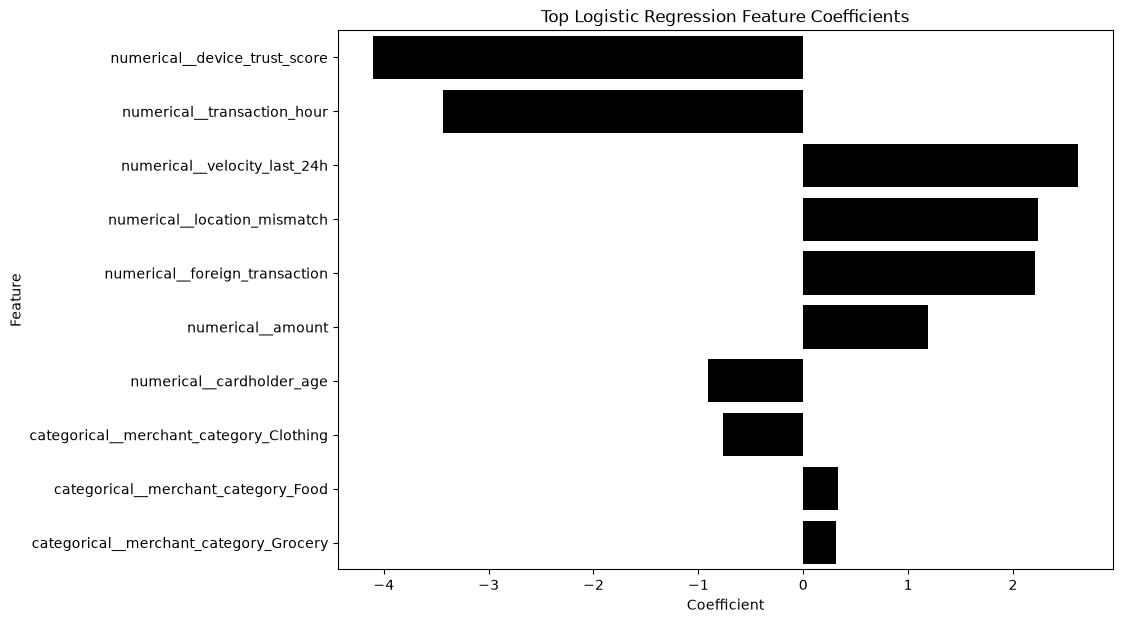

In [34]:
plt.figure(figsize=(10, 7))

top_coefficients = logistic_coefficients.head(10)

sns.barplot(
    data=top_coefficients,
    x="Coefficient",
    y="Feature",
    color="black"
)

plt.title("Top Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

In [35]:
# ============================================
# Q9C - Random Forest Feature Importance
# ============================================

rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print(rf_importance.head(15))

                                       Feature  Importance
1                  numerical__transaction_hour    0.267907
4                numerical__device_trust_score    0.215041
2               numerical__foreign_transaction    0.143083
5                 numerical__velocity_last_24h    0.129957
3                 numerical__location_mismatch    0.119551
0                            numerical__amount    0.024552
8   categorical__merchant_category_Electronics    0.022542
10      categorical__merchant_category_Grocery    0.017502
11       categorical__merchant_category_Travel    0.017165
6                    numerical__cardholder_age    0.016814
9          categorical__merchant_category_Food    0.014773
7      categorical__merchant_category_Clothing    0.011113


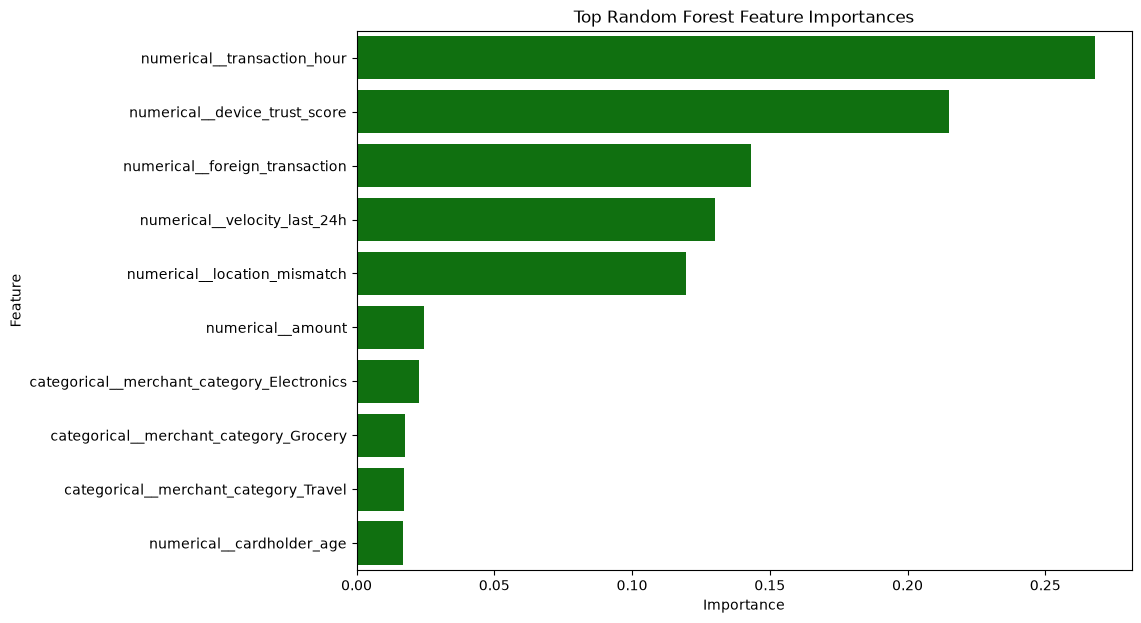

In [36]:
plt.figure(figsize=(10, 7))

top_rf_features = rf_importance.head(10)

sns.barplot(
    data=top_rf_features,
    x="Importance",
    y="Feature",
    color="green"
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

##  Scalability

If the fraud detection system needs to process 1 million transactions per hour, the system would need to be designed for high-throughput and low-latency inference.

1 million transactions per hour is approximately:

1,000,000 / 3,600 ≈ 278 transactions per second.

The trained model itself can potentially handle this rate, particularly a relatively lightweight model such as Logistic Regression. A Random Forest can also support high-throughput batch or parallel inference, although its computational cost depends on the number and depth of trees.

For production deployment, the following approaches could be used:

- Use a trained model for real-time inference rather than retraining for every transaction.
- Use parallel processing and multiple model-serving instances.
- Use batch processing when real-time predictions are not required.
- Store and calculate transaction velocity features efficiently.
- Use a streaming system such as Kafka for high-volume transaction events.
- Use model-serving infrastructure such as FastAPI or another API framework.
- Monitor prediction latency, throughput, fraud detection performance, and data drift.
- Retrain the model periodically using newly labelled fraud transactions.
- Keep the test set separate from production data to avoid data leakage.
- Consider distributed processing technologies if transaction volume grows significantly.

At 1 million transactions per hour, the average arrival rate is approximately 278 transactions per second. A production system should therefore be benchmarked under realistic peak traffic rather than relying only on average throughput.

## Conclusion

In this project, a complete Machine Learning pipeline was developed to detect fraudulent financial transactions. The transaction data was explored and preprocessed before dividing it into training and testing datasets using a **stratified split**.

Since the dataset contains significantly fewer fraudulent transactions, **SMOTE** was used on the training data to handle class imbalance. Two Machine Learning models, **Logistic Regression and Random Forest**, were then trained to classify transactions as genuine or fraudulent.

The models were evaluated using **Precision, Recall, F1-Score, and ROC-AUC** to understand their ability to detect fraud and minimize incorrect predictions. Feature analysis was also performed to understand which transaction characteristics contribute to the model's predictions.

Overall, this project demonstrates how Machine Learning can be used to build a practical fraud detection system while addressing important challenges such as **class imbalance, model evaluation, and scalability**.
